In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.eda.plot_time import plot_time
from src.eda.plot_trend import plot_trend
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
consumption_df = pd.read_parquet(r"..\data\processed\consumption.parquet")
generation_df = pd.read_parquet(r"..\data\processed\generation.parquet")

In [3]:
consumption_df = consumption_df.set_index("date")
generation_df = generation_df.set_index("date")

In [4]:
energy_df = consumption_df.join(generation_df, how="inner")

In [5]:
energy_df.head(2)

,time,consumption,hour,total_generation,naturalGas,dammedHydro,lignite,river,importCoal,wind,sun,fueloil,geothermal,asphaltiteCoal,blackCoal,biomass,naphta,lng,importExport,wasteheat
date,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,00:00,27412.81,00:00,27412.81,6926.78,4820.40,5226.32,1900.32,5314.05,1179.51,0.0,176.6,801.09,278.20,189.5,210.96,0,0.0,297.0,92.08
2018-01-01 01:00:00,01:00,26324.39,01:00,26324.39,6603.44,3644.32,5277.19,1877.83,5715.61,1148.46,0.0,174.2,803.21,284.82,205.5,211.67,0,0.0,287.0,91.14


In [6]:
energy_df.drop(["time", "hour"], axis=1, inplace=True)

In [7]:
energy_df.head(2)

,consumption,total_generation,naturalGas,dammedHydro,lignite,river,importCoal,wind,sun,fueloil,geothermal,asphaltiteCoal,blackCoal,biomass,naphta,lng,importExport,wasteheat
date,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,27412.81,27412.81,6926.78,4820.40,5226.32,1900.32,5314.05,1179.51,0.0,176.6,801.09,278.20,189.5,210.96,0,0.0,297.0,92.08
2018-01-01 01:00:00,26324.39,26324.39,6603.44,3644.32,5277.19,1877.83,5715.61,1148.46,0.0,174.2,803.21,284.82,205.5,211.67,0,0.0,287.0,91.14


In [8]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70128 entries, 2018-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   consumption       70128 non-null  float64
 1   total_generation  70128 non-null  float64
 2   naturalGas        70128 non-null  float64
 3   dammedHydro       70128 non-null  float64
 4   lignite           70128 non-null  float64
 5   river             70128 non-null  float64
 6   importCoal        70128 non-null  float64
 7   wind              70128 non-null  float64
 8   sun               70128 non-null  float64
 9   fueloil           70128 non-null  float64
 10  geothermal        70128 non-null  float64
 11  asphaltiteCoal    70128 non-null  float64
 12  blackCoal         70128 non-null  float64
 13  biomass           70128 non-null  float64
 14  naphta            70128 non-null  int64  
 15  lng               70128 non-null  float64
 16  impor

In [9]:
print(energy_df.duplicated().sum())
print(energy_df.isna().sum())

0
consumption         0
total_generation    0
naturalGas          0
dammedHydro         0
lignite             0
river               0
importCoal          0
wind                0
sun                 0
fueloil             0
geothermal          0
asphaltiteCoal      0
blackCoal           0
biomass             0
naphta              0
lng                 0
importExport        0
wasteheat           0
dtype: int64


In [10]:
energy_df.describe()

,consumption,total_generation,naturalGas,dammedHydro,lignite,river,importCoal,wind,sun,fueloil,geothermal,asphaltiteCoal,blackCoal,biomass,naphta,lng,importExport,wasteheat
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.0,70128.000000,70128.000000,70128.000000
mean,36283.168037,34967.969936,8561.350534,5611.868244,4822.297439,2140.828702,7498.331937,3431.451869,311.062329,83.967199,1080.522594,220.283714,441.237566,685.015720,0.0,0.013540,-2.708041,82.443951
std,6264.779484,5667.259609,4056.095206,2887.755777,625.803275,1296.199992,1945.498227,2092.835454,619.549246,47.663660,179.951863,88.818855,118.406824,273.305812,0.0,0.145072,380.488386,13.053770
min,15333.300000,11175.310000,276.290000,296.690000,1701.420000,205.200000,956.350000,42.530000,-2.980000,0.000000,525.110000,0.000000,77.500000,202.580000,0.0,0.000000,-3130.500000,30.690000
25%,31597.605000,30915.872500,5404.217500,3292.365000,4465.325000,1113.365000,6211.375000,1720.917500,0.000000,39.000000,951.110000,183.250000,345.500000,401.180000,0.0,0.000000,-259.180000,74.190000
50%,36045.640000,34845.075000,8666.295000,5326.520000,4859.185000,1661.920000,7896.195000,3085.420000,5.505000,83.460000,1106.205000,220.790000,442.720000,763.190000,0.0,0.000000,-36.000000,82.790000
75%,40496.195000,38887.622500,11465.292500,7637.975000,5237.062500,3029.937500,8820.460000,4801.277500,251.725000,94.150000,1231.032500,289.230000,546.752500,941.480000,0.0,0.000000,266.215000,91.510000
max,59503.670000,56219.060000,19453.650000,16722.490000,6984.150000,6103.590000,10172.670000,10612.450000,3394.370000,237.600000,1422.370000,368.720000,692.620000,1082.430000,0.0,1.880000,7875.850000,127.760000


In [11]:
energy_df["deficit"] = energy_df["consumption"] - energy_df["total_generation"]
energy_df["hour"] = energy_df.index.hour
energy_df["dayofweek"] = energy_df.index.dayofweek
energy_df["day_name"] = energy_df.index.day_name()
energy_df["day"] = energy_df.index.day
energy_df["is_weekend"] = (energy_df["dayofweek"] >= 5).astype(int)
energy_df["week"] = energy_df.index.isocalendar().week
energy_df["month"] = energy_df.index.month
energy_df["year"] = energy_df.index.year

In [12]:
energy_df.columns

Index(['consumption', 'total_generation', 'naturalGas', 'dammedHydro',
       'lignite', 'river', 'importCoal', 'wind', 'sun', 'fueloil',
       'geothermal', 'asphaltiteCoal', 'blackCoal', 'biomass', 'naphta', 'lng',
       'importExport', 'wasteheat', 'deficit', 'hour', 'dayofweek', 'day_name',
       'day', 'is_weekend', 'week', 'month', 'year'],
      dtype='object')

### Exploratory Data Analysis

In [13]:
sns.set_style("darkgrid")

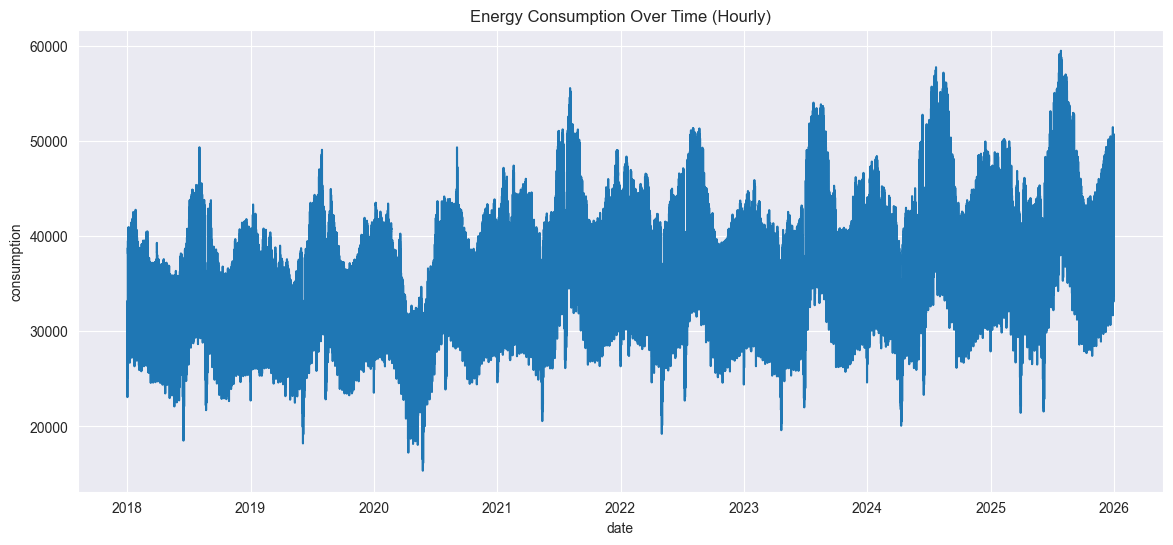

In [14]:
plt.figure(figsize=(14,6))
sns.lineplot(data=energy_df, x = energy_df.index, y = "consumption")
plt.title("Energy Consumption Over Time (Hourly)")
plt.show()

In [15]:
energy_cols = ['consumption', 'total_generation', 'deficit']
daily_df = energy_df[energy_cols].resample("D").sum()
monthly_df = energy_df[energy_cols].resample("ME").sum()

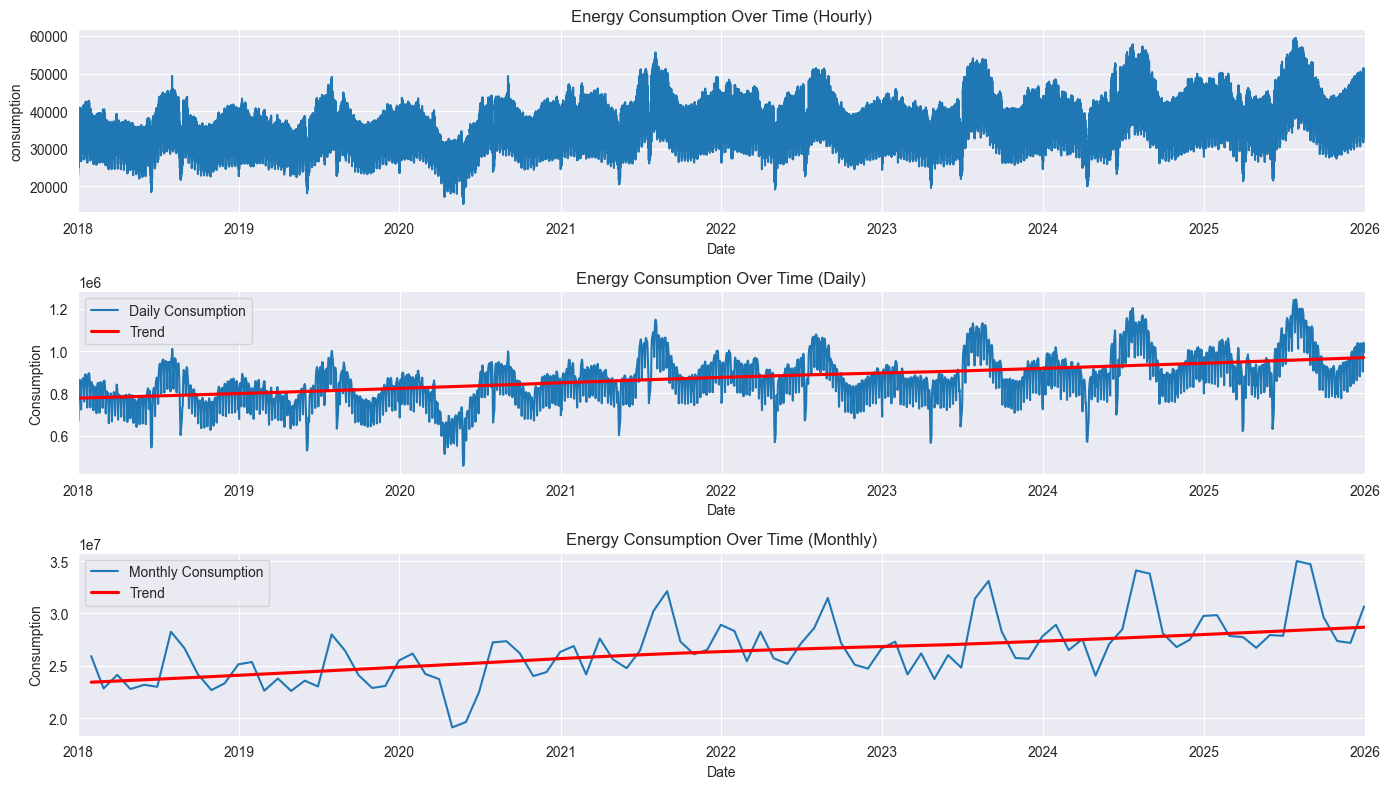

In [16]:
fig, ax = plt.subplots(3,1,figsize=(14,8))

sns.lineplot(data=energy_df, x = energy_df.index, y = "consumption", ax=ax[0])
ax[0].set_title("Energy Consumption Over Time (Hourly)")
ax[0].set_xlabel("Date")
ax[0].set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-01-01"))
plot_trend(df=daily_df, y="consumption", label="Daily Consumption", ax=ax[1], title="Energy Consumption Over Time (Daily)")
plot_trend(df=monthly_df, y="consumption", label="Monthly Consumption", ax=ax[2], title="Energy Consumption Over Time (Monthly)")

plt.tight_layout()
plt.show()

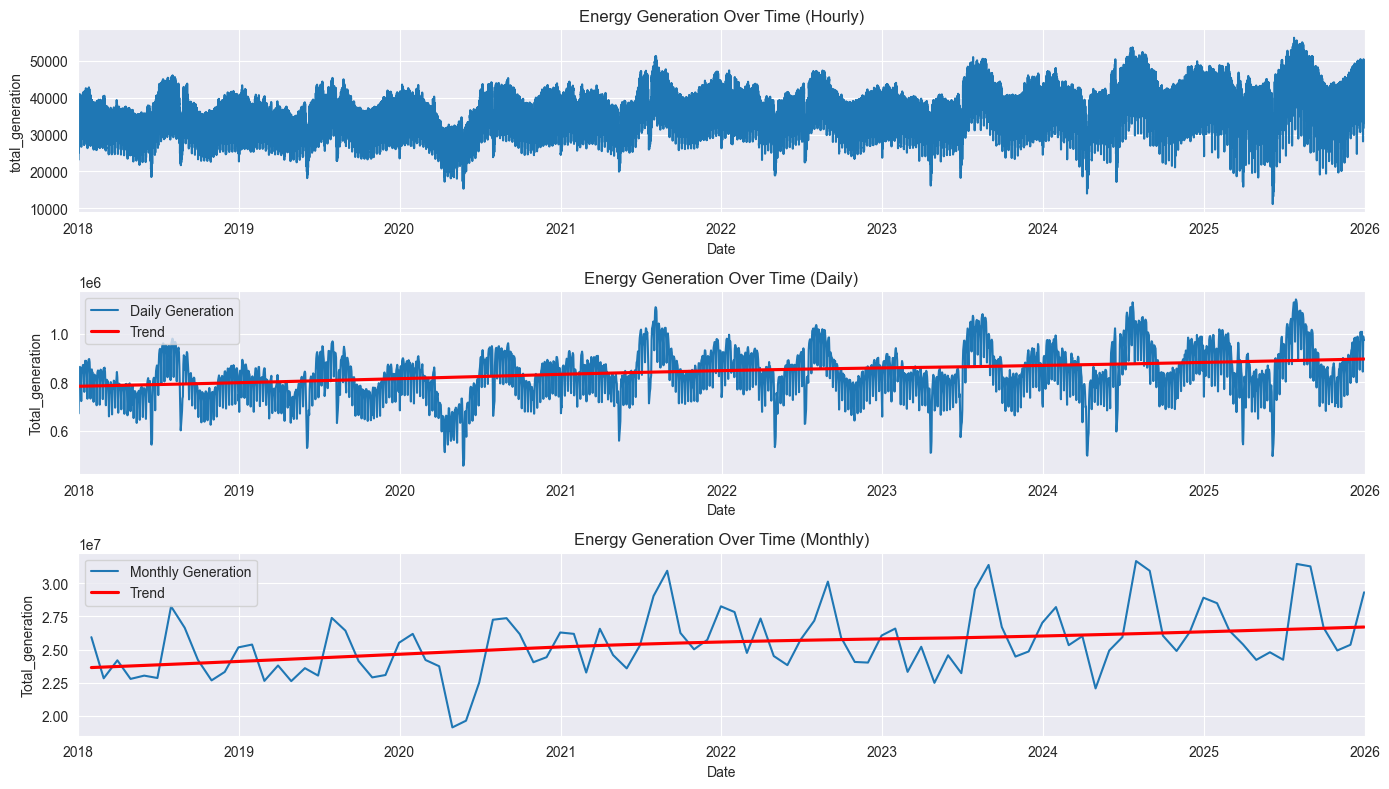

In [17]:
fig, ax = plt.subplots(3,1,figsize=(14,8))

sns.lineplot(data=energy_df, x = energy_df.index, y = "total_generation", ax=ax[0])
ax[0].set_title("Energy Generation Over Time (Hourly)")
ax[0].set_xlabel("Date")
ax[0].set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-01-01"))
plot_trend(df=daily_df, y="total_generation", label="Daily Generation", ax=ax[1], title="Energy Generation Over Time (Daily)")
plot_trend(df=monthly_df, y="total_generation", label="Monthly Generation", ax=ax[2], title="Energy Generation Over Time (Monthly)")

plt.tight_layout()
plt.show()

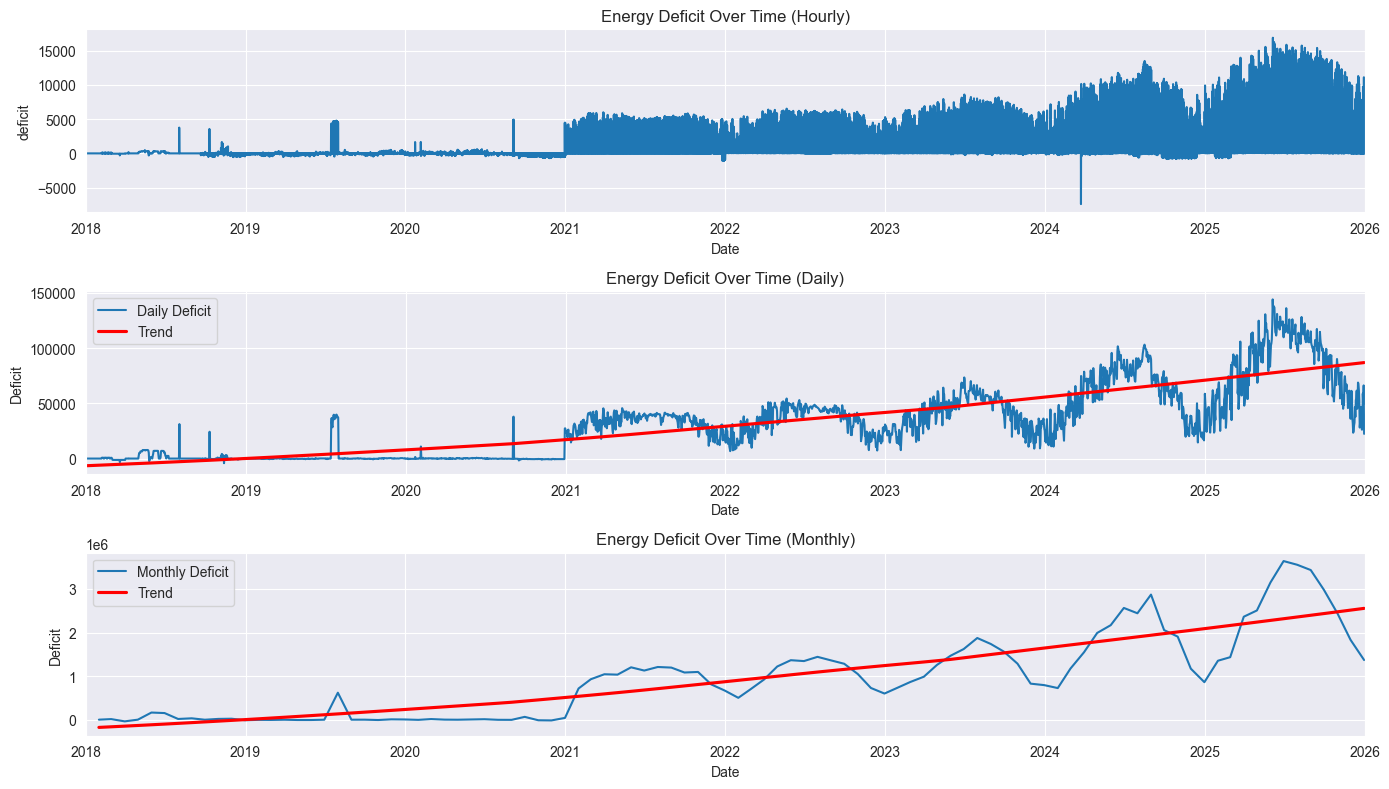

In [18]:
fig, ax = plt.subplots(3,1,figsize=(14,8))

sns.lineplot(data=energy_df, x = energy_df.index, y = "deficit", ax=ax[0])
ax[0].set_title("Energy Deficit Over Time (Hourly)")
ax[0].set_xlabel("Date")
ax[0].set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-01-01"))
plot_trend(df=daily_df, y="deficit", label="Daily Deficit", ax=ax[1], title="Energy Deficit Over Time (Daily)")
plot_trend(df=monthly_df, y="deficit", label="Monthly Deficit", ax=ax[2], title="Energy Deficit Over Time (Monthly)")

plt.tight_layout()
plt.show()

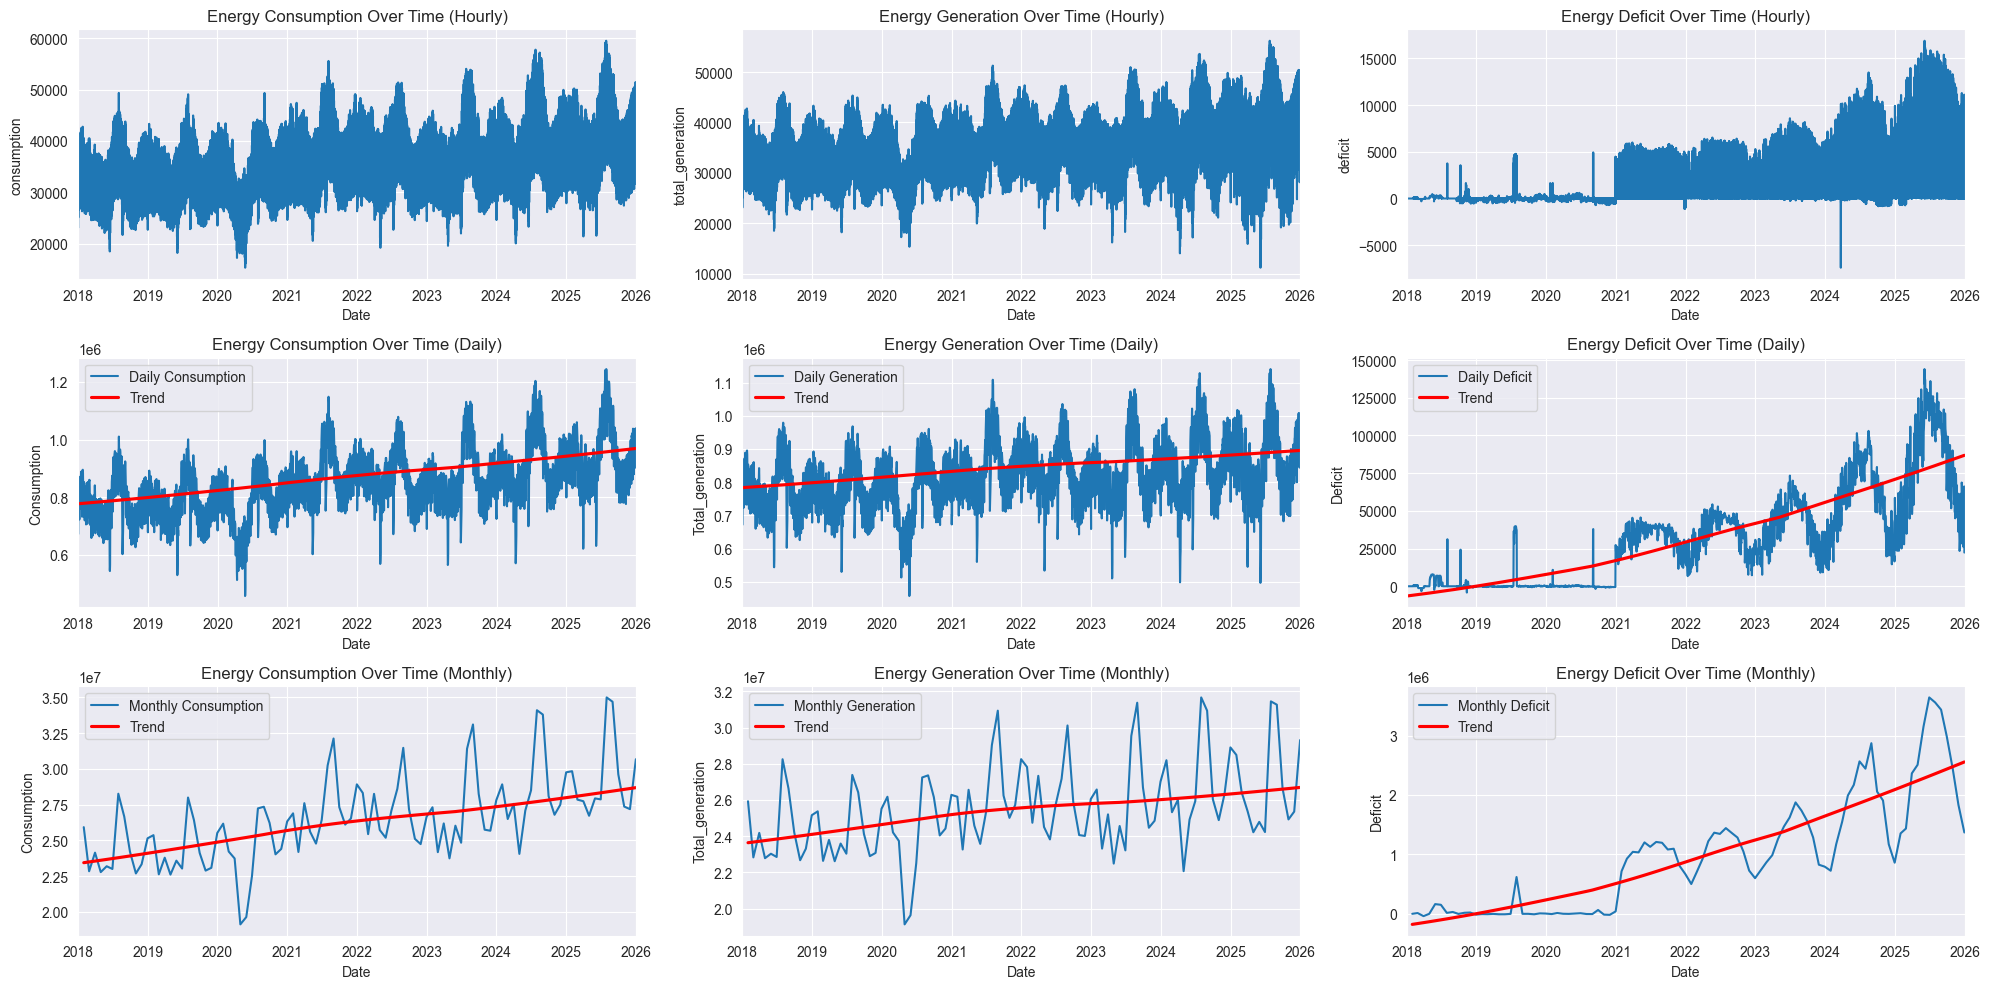

In [19]:
fig, ax = plt.subplots(3,3,figsize=(20,10))


# Consumption
sns.lineplot(data=energy_df, x = energy_df.index, y = "consumption", ax=ax[0,0])
ax[0,0].set_title("Energy Consumption Over Time (Hourly)")
ax[0,0].set_xlabel("Date")
ax[0,0].set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-01-01"))
plot_trend(df=daily_df, y="consumption", label="Daily Consumption", ax=ax[1,0], title="Energy Consumption Over Time (Daily)")
plot_trend(df=monthly_df, y="consumption", label="Monthly Consumption", ax=ax[2,0], title="Energy Consumption Over Time (Monthly)")


# Generation
sns.lineplot(data=energy_df, x = energy_df.index, y = "total_generation", ax=ax[0,1])
ax[0,1].set_title("Energy Generation Over Time (Hourly)")
ax[0,1].set_xlabel("Date")
ax[0,1].set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-01-01"))
plot_trend(df=daily_df, y="total_generation", label="Daily Generation", ax=ax[1,1], title="Energy Generation Over Time (Daily)")
plot_trend(df=monthly_df, y="total_generation", label="Monthly Generation", ax=ax[2,1], title="Energy Generation Over Time (Monthly)")


# Deficit
sns.lineplot(data=energy_df, x = energy_df.index, y = "deficit", ax=ax[0,2])
ax[0,2].set_title("Energy Deficit Over Time (Hourly)")
ax[0,2].set_xlabel("Date")
ax[0,2].set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-01-01"))
plot_trend(df=daily_df, y="deficit", label="Daily Deficit", ax=ax[1,2], title="Energy Deficit Over Time (Daily)")
plot_trend(df=monthly_df, y="deficit", label="Monthly Deficit", ax=ax[2,2], title="Energy Deficit Over Time (Monthly)")

plt.tight_layout()
plt.show()

Consumption and generation show a positive linear trend. The slope for generation is flatter than the slope for consumption. Annual patterns exist in both consumption and generation data.
There is a dip in consumption and generation data between 2020 and early 2021 can be caused by COVID-19 lockdown. After that the positive trend continues in both series.
Deficit fluctuates around zero with occasional spikes before 2021. After 2021 it is large and consistent with a strong upward trend.

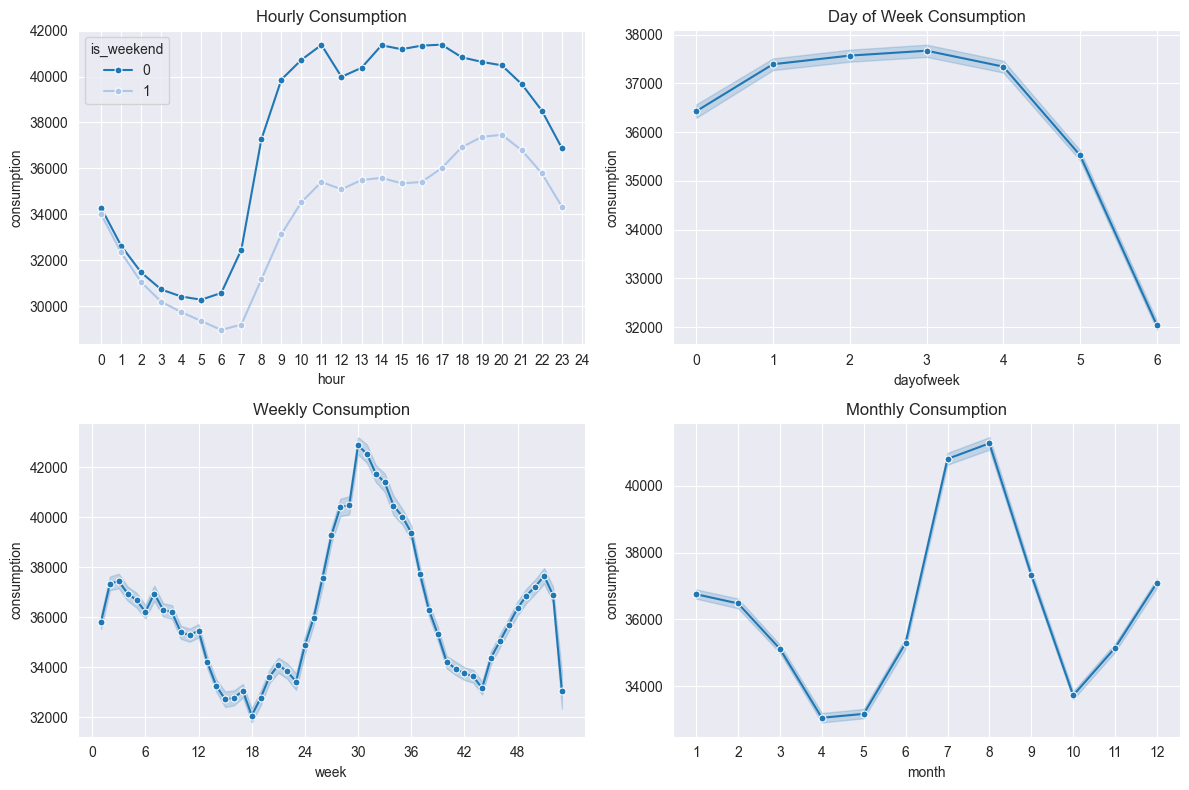

In [20]:
figure, ax = plt.subplots(2,2, figsize=(12,8))
hourly_plot = plot_time(df=energy_df, x="hour", y="consumption", ax=ax[0,0], groupby="is_weekend", marker="o", title="Hourly Consumption")
dow_plot = plot_time(df=energy_df, x="dayofweek", y="consumption", ax=ax[0,1], marker="o", title="Day of Week Consumption")
weekly_plot = plot_time(df=energy_df, x="week", y="consumption", ax=ax[1,0], marker="o", title="Weekly Consumption")
monthly_plot = plot_time(df=energy_df, x="month", y="consumption", ax=ax[1,1], marker="o", title="Monthly Consumption")

plt.tight_layout()
plt.show()

Weekdays have much higher consumption levels than weekends. Consumption is high and stable from Monday through Friday then declines and reaches the lowest level on Sunday.
Seasonally, the lowest consumption occurs during spring (April and May) and fall (October). Consumption levels rise toward summer and peaks in July and August. This is likely driven by cooling demand which is stronger than heating demand since summer consumption is higher than winter consumption.

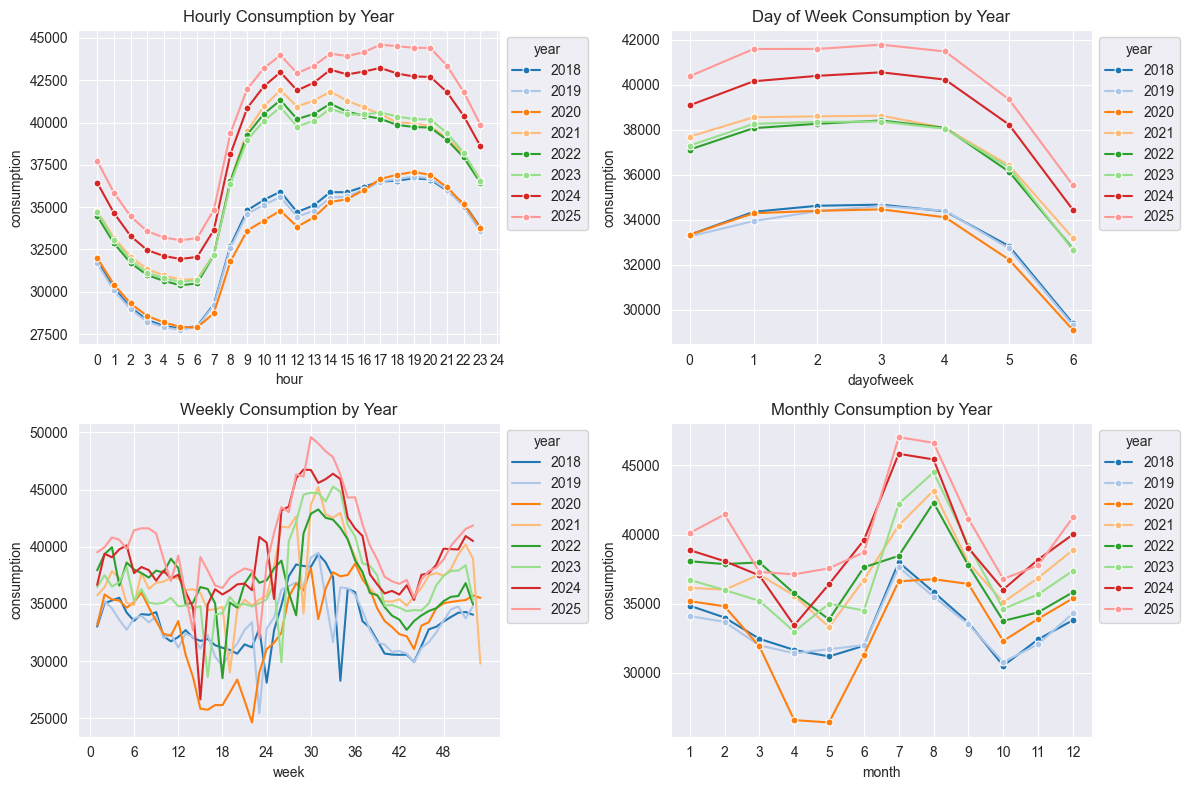

In [21]:
figure, ax = plt.subplots(2,2, figsize=(12,8))
hourly_year_plot = plot_time(df=energy_df, x="hour", y="consumption", ax=ax[0,0], groupby="year", marker="o", title="Hourly Consumption by Year")
dow_year_plot = plot_time(df=energy_df, x="dayofweek", y="consumption", ax=ax[0,1], groupby="year", marker="o", title="Day of Week Consumption by Year")
weekly_year_plot = plot_time(df=energy_df, x="week", y="consumption", ax=ax[1,0], groupby="year", title="Weekly Consumption by Year")
monthly_year_plot = plot_time(df=energy_df, x="month", y="consumption", ax=ax[1,1], groupby="year", marker="o", title="Monthly Consumption by Year")

hourly_year_plot.legend(title="year", loc="upper left", bbox_to_anchor=(1, 1))
dow_year_plot.legend(title="year", loc="upper left", bbox_to_anchor=(1, 1))
weekly_year_plot.legend(title="year", loc="upper left", bbox_to_anchor=(1, 1))
monthly_year_plot.legend(title="year", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

The shapes are similar and consistent across the years from 2018 to 2025. The total consumption shifts upward over time indicating the positive trend.

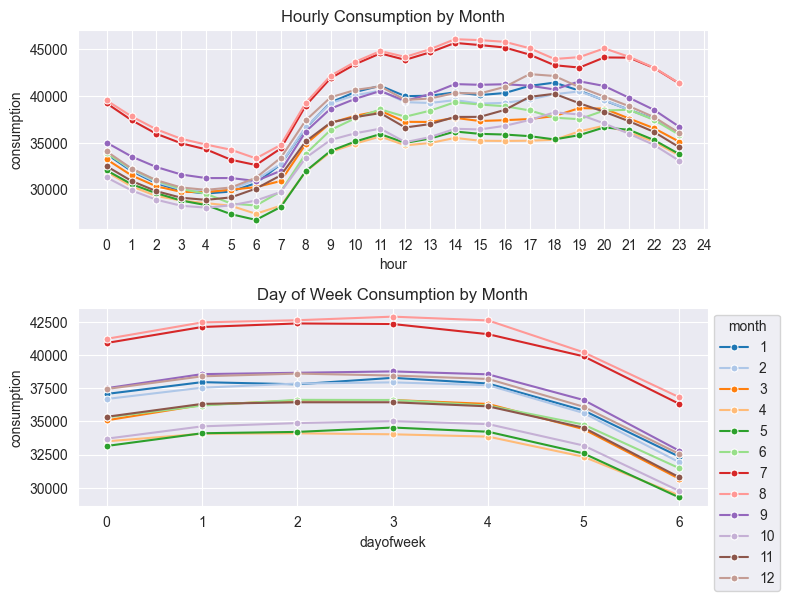

In [22]:
figure, ax = plt.subplots(2,1, figsize=(8,6))
hourly_month_plot = plot_time(df=energy_df, x="hour", y="consumption", ax=ax[0], groupby="month", marker="o", title="Hourly Consumption by Month")
dow_month_plot = plot_time(df=energy_df, x="dayofweek", y="consumption", ax=ax[1], groupby="month", marker="o", title="Day of Week Consumption by Month")

hourly_month_plot.legend_.remove()
dow_month_plot.legend(title="month", loc="best", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

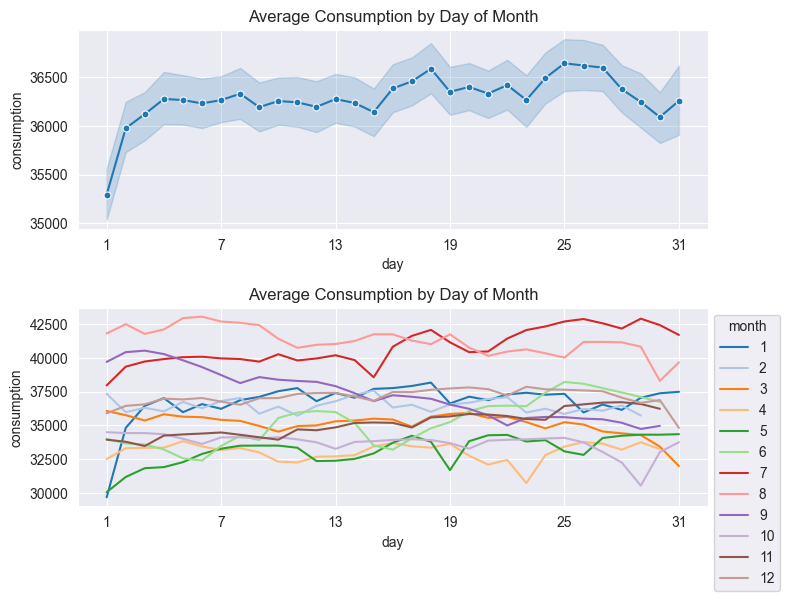

In [23]:
figure, ax = plt.subplots(2,1, figsize=(8,6))
daily_plot = plot_time(df=energy_df, x="day", y="consumption", ax=ax[0], marker="o", title="Average Consumption by Day of Month")
daily_month_plot = plot_time(df=energy_df, x="day", y="consumption", ax=ax[1], groupby="month", title="Average Consumption by Day of Month")

daily_month_plot.legend(title="month", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

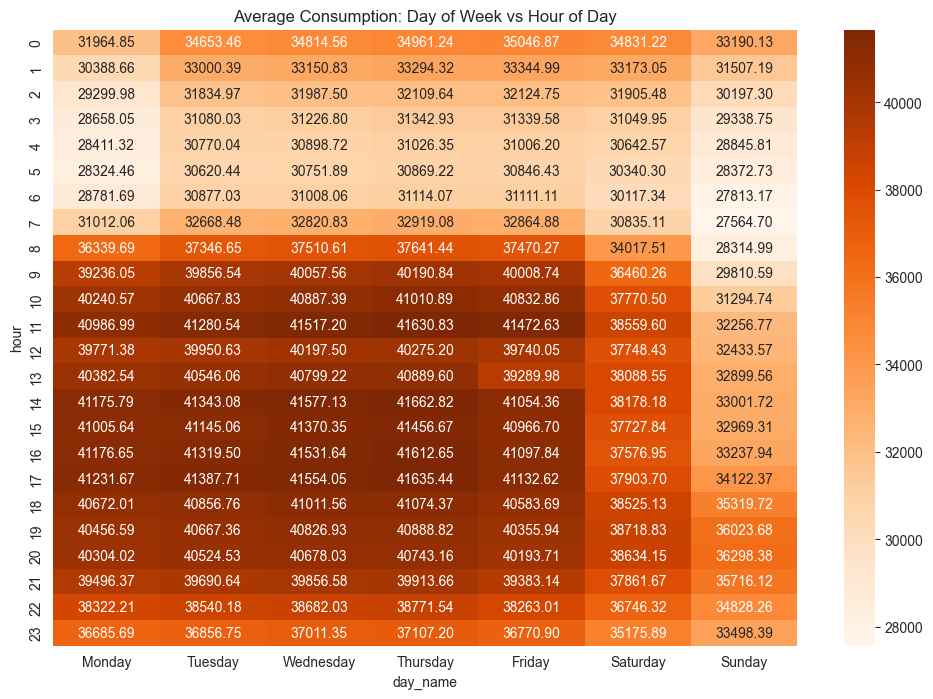

In [24]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
energy_df["day_name"] = energy_df["day_name"] = pd.Categorical(energy_df["day_name"],
                                categories=day_order,
                                ordered=True)
pivot_df = energy_df.pivot_table(index="hour", columns="day_name", values="consumption", aggfunc="mean", observed=False)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap="Oranges", fmt=".2f",annot=True)
plt.title("Average Consumption: Day of Week vs Hour of Day")
plt.show()

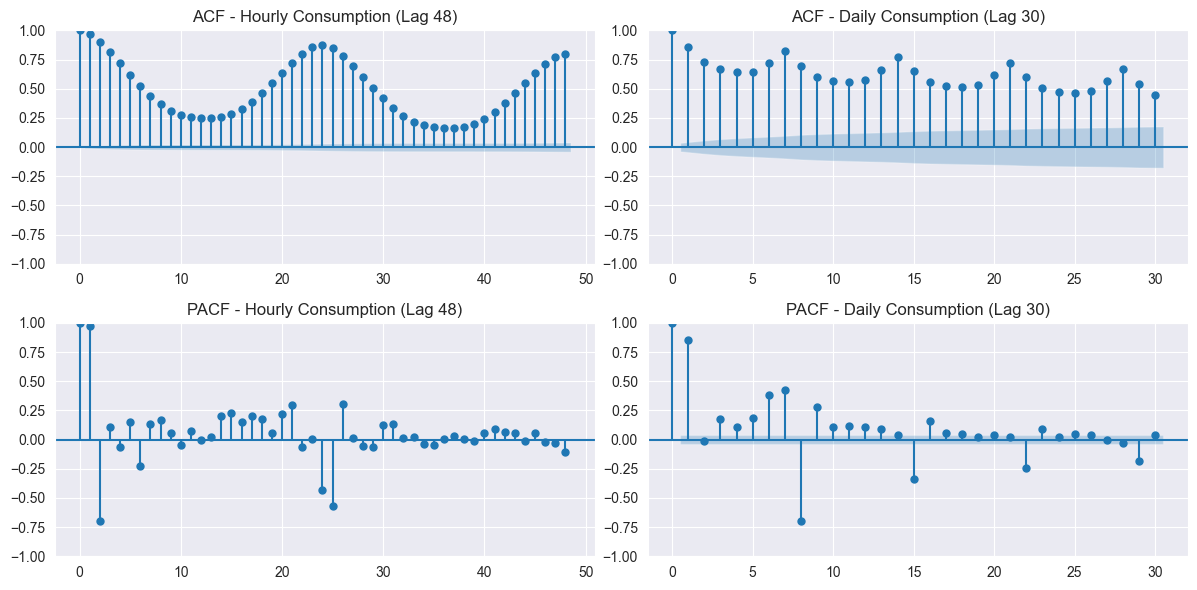

In [25]:
fig, ax = plt.subplots(2,2, figsize=(12,6))

plot_acf(ax=ax[0,0], x=energy_df["consumption"], lags=48, title="ACF - Hourly Consumption (Lag 48)")
plot_pacf(ax=ax[1,0], x=energy_df["consumption"], lags=48, title="PACF - Hourly Consumption (Lag 48)")

plot_acf(ax=ax[0,1], x=daily_df["consumption"], lags=30, title="ACF - Daily Consumption (Lag 30)")
plot_pacf(ax=ax[1,1], x=daily_df["consumption"], lags=30, title="PACF - Daily Consumption (Lag 30)")

plt.tight_layout()
plt.show()